In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

In [2]:
TICKERS =  ["AAPL", "NVDA"]

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR  = REPO_ROOT / "data" / "raw"
OUT_DIR   = REPO_ROOT / "data" / "processed"
FIG_DIR   = REPO_ROOT / "reports" / "figures"

COLORS = {
    "AAPL": "#1f77b4",   # blue
    "NVDA": "#2ca02c",   # green
}

In [3]:
def load_stock(ticker: str) -> pd.DataFrame:
    path = DATA_DIR / f"{ticker}_data.csv"
    return pd.read_csv(path, index_col="Date", parse_dates=True)

stock_data = {ticker: load_stock(ticker) for ticker in TICKERS}

stock_data["AAPL"].head()

,Open,High,Low,Close,Volume,Daily_Return,MA_20,MA_50,Volatility_20
Date,,,,,,,,,
2021-01-04,129.734330,129.821775,123.165994,125.740860,143301900,NaN,NaN,NaN,NaN
2021-01-05,125.235592,128.004792,124.788628,127.295479,97664900,0.012364,NaN,NaN,NaN
2021-01-06,124.098745,127.334331,122.796735,123.010498,155088000,-0.033662,NaN,NaN,NaN
2021-01-07,124.720594,127.897884,124.234771,127.208008,109578200,0.034123,NaN,NaN,NaN
2021-01-08,128.675231,128.869572,126.537610,128.306015,105158200,0.008632,NaN,NaN,NaN


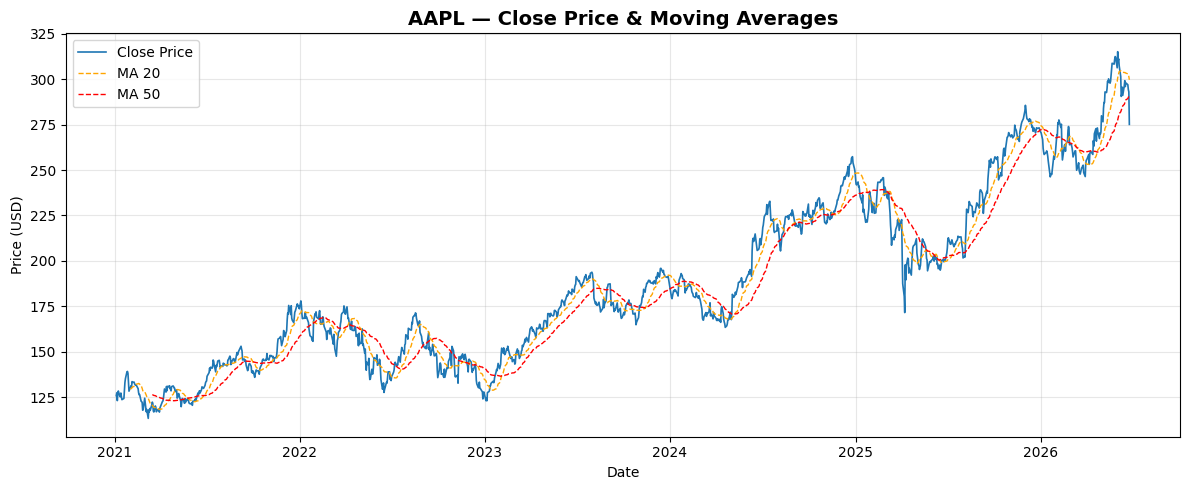

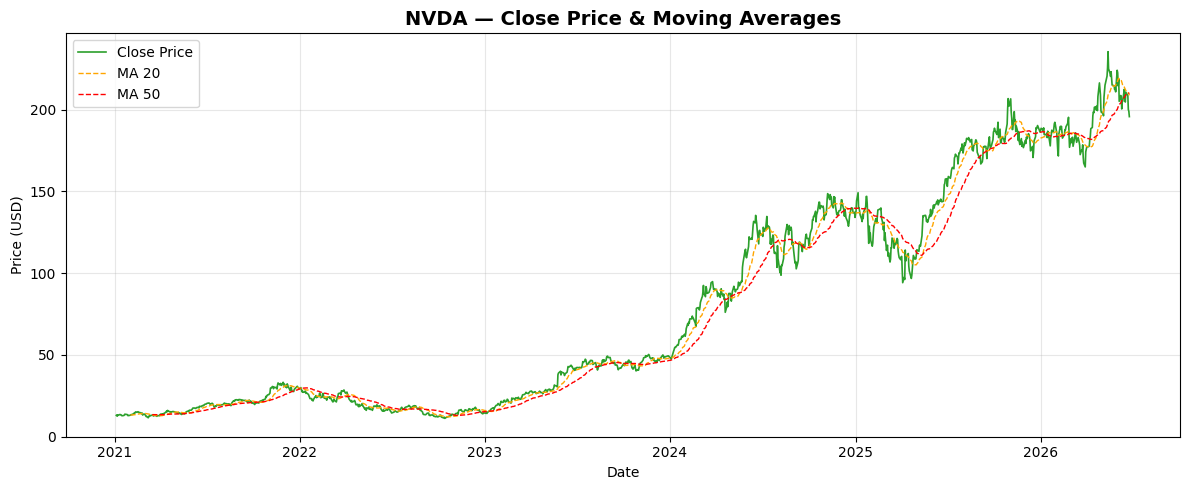

In [4]:
def plot_price_ma(ticker: str, df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(12, 5))
    color = COLORS[ticker]
 
    ax.plot(df.index, df["Close"],  color=color,   linewidth=1.2, label="Close Price")
    ax.plot(df.index, df["MA_20"],  color="orange", linewidth=1,   linestyle="--", label="MA 20")
    ax.plot(df.index, df["MA_50"],  color="red",    linewidth=1,   linestyle="--", label="MA 50")
 
    ax.set_title(f"{ticker} — Close Price & Moving Averages", fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (USD)")
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
 

for ticker, df in stock_data.items():
    plot_price_ma(ticker, df)

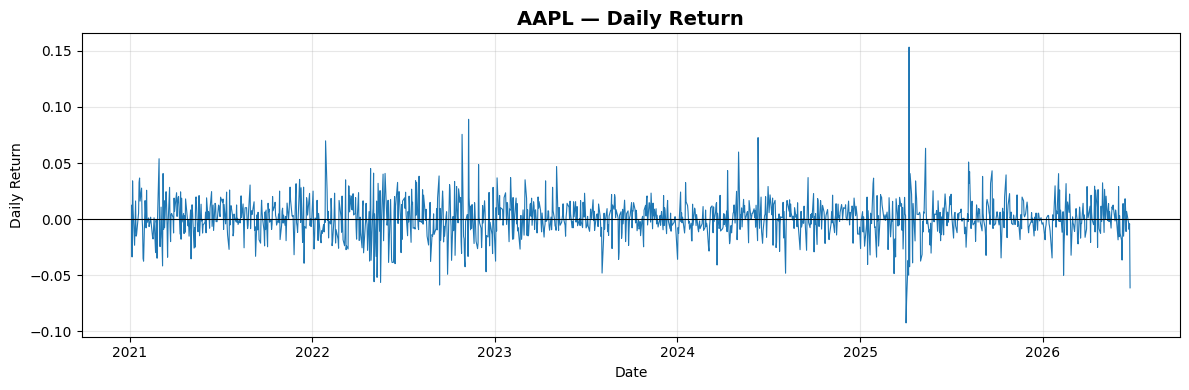

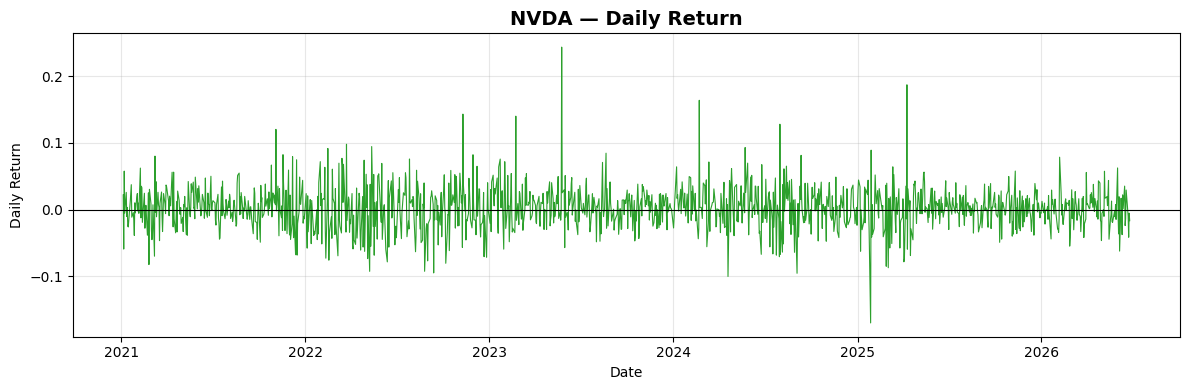

In [5]:
def plot_daily_return(ticker: str, df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(12, 4))
    color = COLORS[ticker]

    ax.plot(df.index, df["Daily_Return"], color=color, linewidth=0.8)

    ax.set_title(f"{ticker} — Daily Return", fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Daily Return")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.3)
    fig.tight_layout()


for ticker, df in stock_data.items():
    plot_daily_return(ticker, df)